# Visualizzazioni qwen base

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

In [2]:
sns.set_theme(style="darkgrid")
colors = edgecolors = sns.color_palette("flare")

# global attribute
# per le lettere
offset = 5
plt.rcParams["font.family"] = "DIN Alternate"
plt.rcParams["axes.titlesize"] = 20 + offset
plt.rcParams["axes.labelsize"] = 15 + offset
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["xtick.labelsize"]   = 15 + offset
plt.rcParams["ytick.labelsize"]   = 15 + offset
plt.rcParams["legend.fontsize"]   = 15 + offset
plt.rcParams["legend.title_fontsize"] = 15 + offset

# per il colore del grafico 
plt.rcParams["axes.facecolor"] = "white"
#plt.rcParams["figure.facecolor"] =  "#ca6702"
plt.rcParams["grid.color"] = "#fed0bb"
plt.rcParams["axes.edgecolor"] = "#fed0bb"


In [3]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name_wo_edge.csv"
df = pd.read_csv(RESULT_TOT)
print(df.columns)
df['model'].unique()

Index(['model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'function_calls', 'push_data_response', 'ore_ordinarie_acc',
       'ore_straordinarie_acc', 'ore_viaggio_acc', 'inefficiency_acc',
       'tot_acc', 'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'count_function_calls', 'failure_reason',
       'sentence_similarity_score_note',
       'sentence_similarity_score_inefficiency', 'n_relevant_fields',
       'failure_reason_2'],
      dtype='str')


<ArrowStringArray>
[                   'qwen-chat-agent-4-v2',
                          'chat-qwen-base',
                       'qwen-chat-agent-6',
                        'qwen-extractor-3',
                        'qwen-extractor-4',
                        'qwen-extractor-2',
    'qwen-chat-extractor-tuned-lora-16-v1',
                    'qwen-chat-agent-5-v1',
                       'qwen-chat-agent-7',
          'qwen-chat-agent-8-wo-embedding',
                      'qwen-chat-agent-12',
                       'qwen-chat-agent-9',
                'qwen-extractor-5-lora-32',
              'qwen-extractor-6-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
         'qwen_chat_agent_13_dense_reward',
                     'qwen_chat_agent_sft',
                      'qwen_extractor_sft',
                       'qwen_combined_sft',
                      'qwen_combined_grpo']
Length: 20, dtype: str

In [4]:
target ='base'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-base']
models

['chat-qwen-base']

0.46 	+-0.0203571170187945


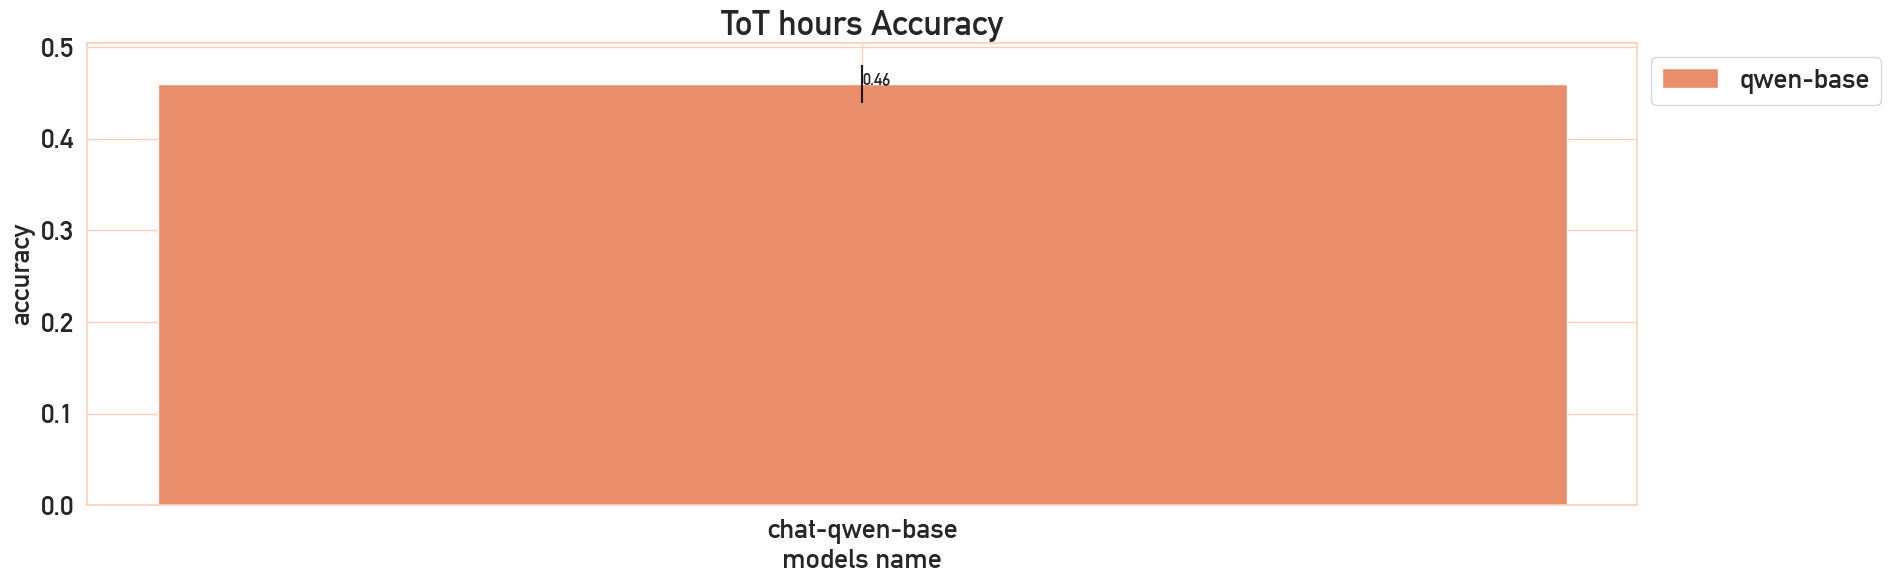

In [5]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    g = df.loc[df['model'] == model]
    acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
      )                                                                                                                                                                                                                                                                                                      
    # effective n = total field evaluations (not number of rows)                                                                                          
    n = g['n_relevant_fields'].sum()
    # intervallo di confidenza al 90 %
    CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, label=labels, color=colors)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

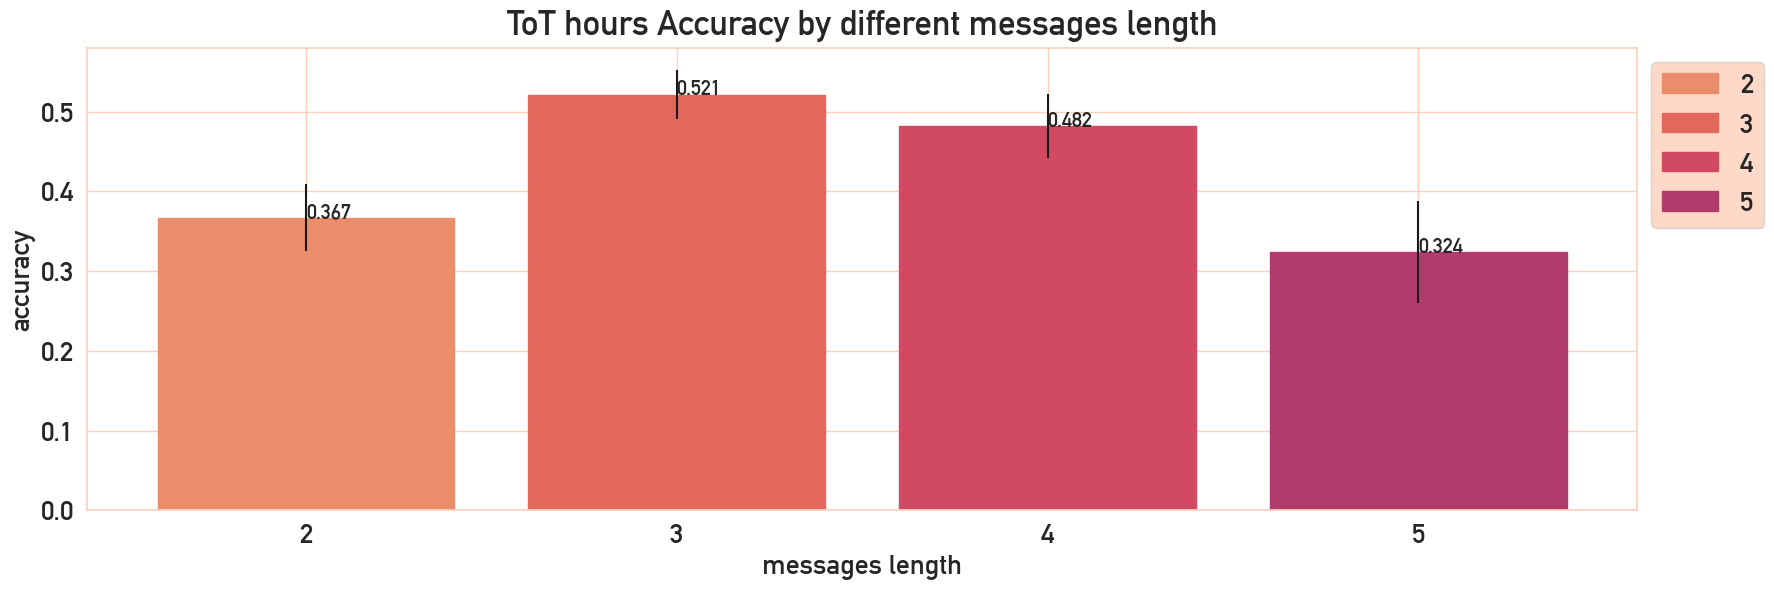

In [7]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    l_msg = np.sort(df['L_MESSAGGI'].unique())
    for length_m in l_msg:
        g = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)]
        
        acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
        )                                                                                                                                                                                                                                                                                                      
        # effective n = total field evaluations (not number of rows)                                                                                          
        n = g['n_relevant_fields'].sum()
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,media_group, yerr=CI_group, label=l_msg, color=colors, edgecolor=edgecolors)
    add_labels(l_msg,media_group)
    plt.title(f"ToT hours Accuracy by different messages length", pad=10)
    plt.xlabel("messages length")
    plt.xticks(l_msg)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


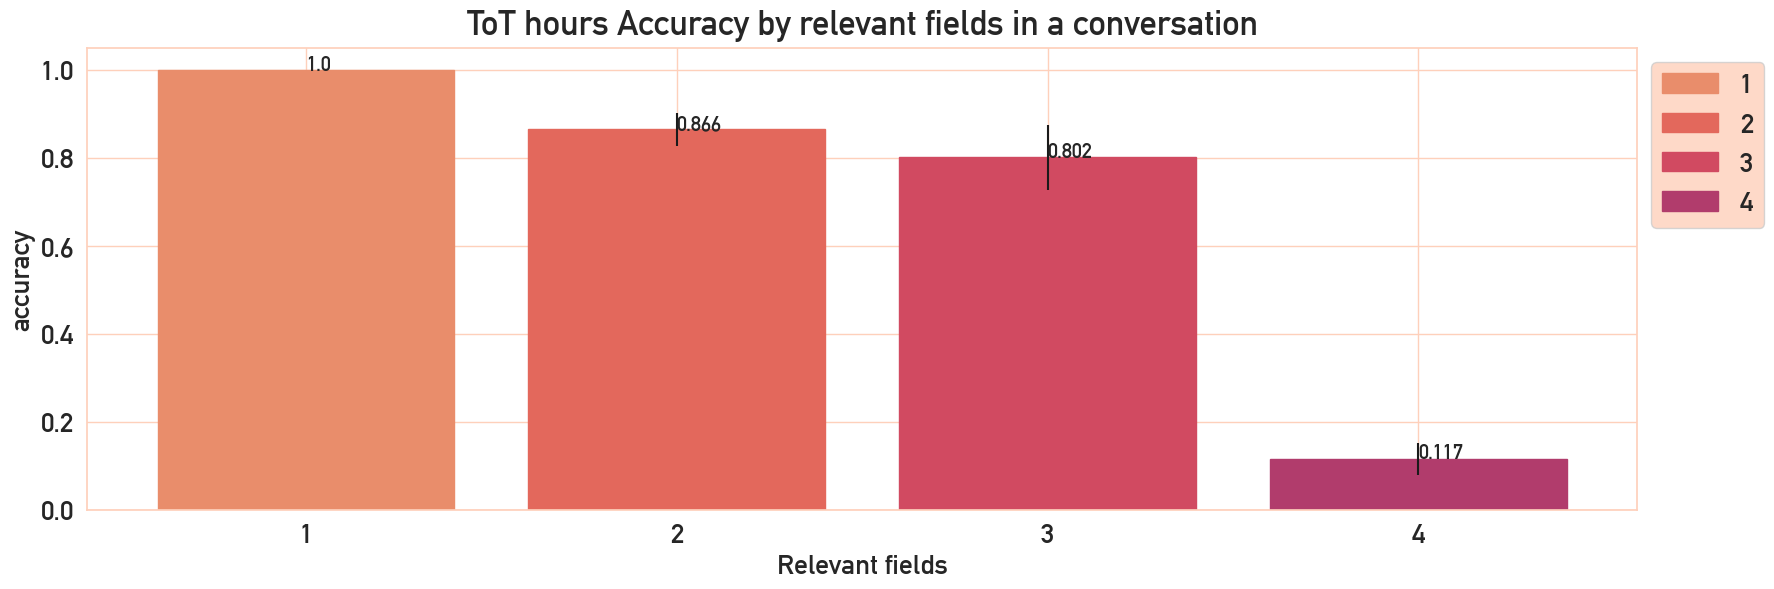

In [12]:
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    n_fields = np.sort(df['n_relevant_fields'].unique())[1:]
    for n_field in n_fields:
        acc_media = round(df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)]['tot_acc'].mean(),3)
        n = len(df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)])
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(n_fields,media_group, yerr=CI_group, label=n_fields, color=colors, edgecolor=colors)
    add_labels(n_fields,media_group)
    plt.title(f"ToT hours Accuracy by relevant fields in a conversation", pad=10)
    plt.xlabel("Relevant fields")
    plt.xticks(n_fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

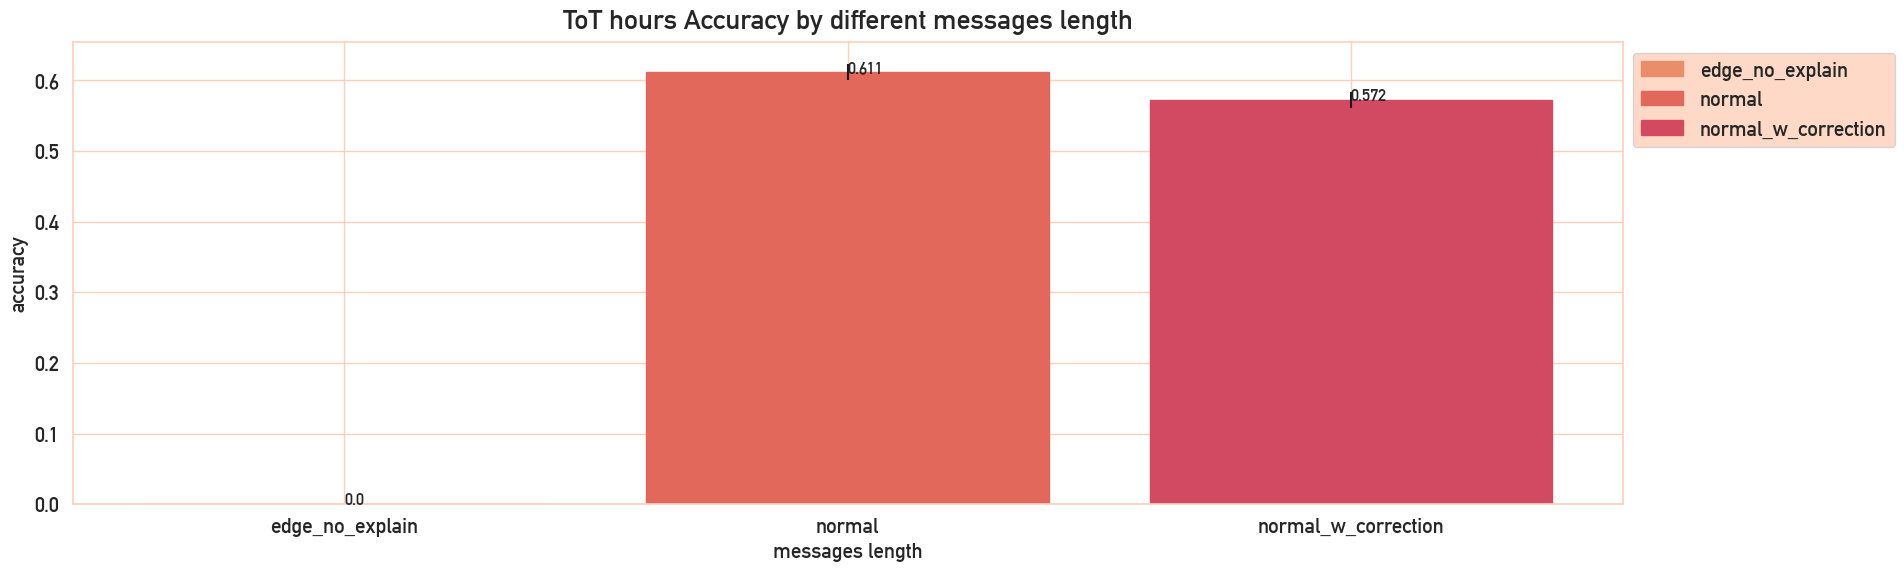

In [ ]:
# accuracy a tipi di schema
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())


for model in models:
    media_group = []
    CI_group = []
    schemas = np.sort(df['TYPE_EVAL'].unique())
    for schema in schemas:
        acc_media = round(df.loc[(df['model'] == model)  & (df['TYPE_EVAL'] == schema)]['tot_acc'].mean(),3)
        n = len(df)
        # intervallo di confidenza al 99 %
        CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(schemas,media_group, yerr=CI_group, label=schemas, color=colors, edgecolor=edgecolors)
    add_labels(schemas,media_group)
    plt.title(f"ToT hours Accuracy by different messages length", pad=10)
    plt.xlabel("messages length")
    plt.xticks(schemas)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


In [18]:
df["sentence_similarity_score_note"] = df["sentence_similarity_score_note"].clip(lower=0)

In [19]:
df["sentence_similarity_score_note"].min()

np.float64(0.0)

Text(0.5, 1.0, "Sentence Similarity Distribution for label 'note'")

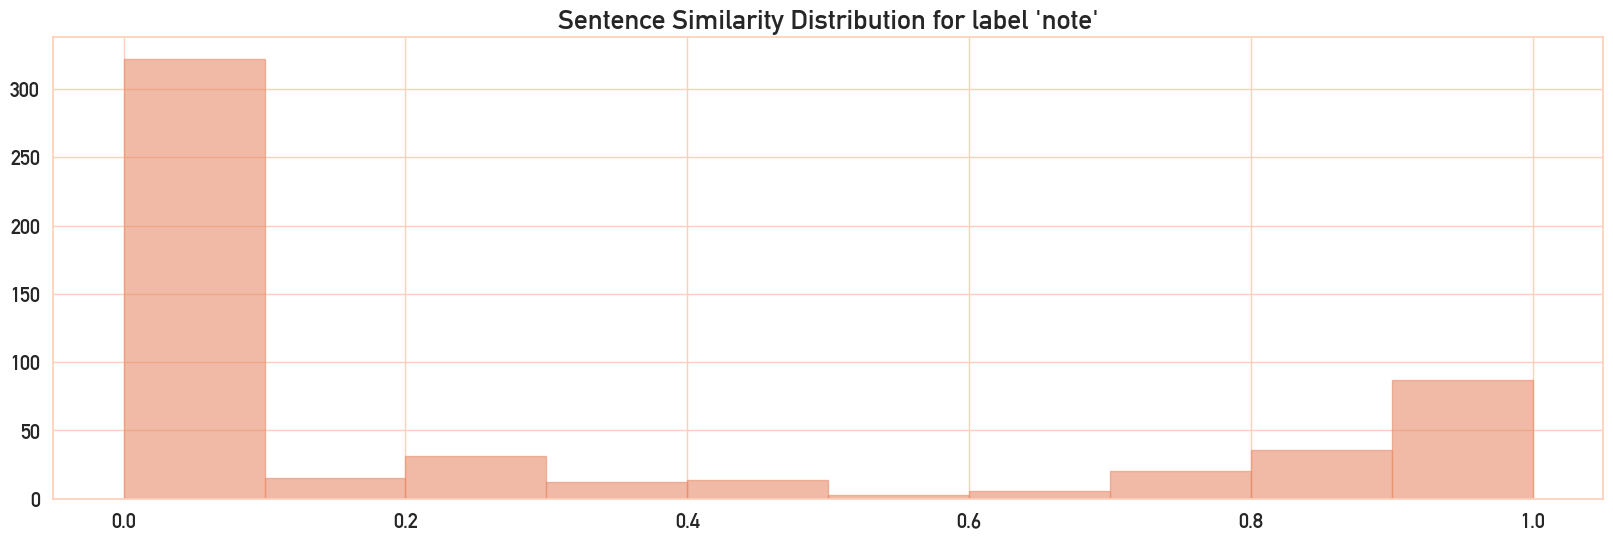

In [67]:
# distribuzione cosine similarity per il campo note
plt.figure(figsize=(20,6))
all_data = []
for model in models:
    data = df.loc[(df['model'] == model) & 
                  (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note']
    all_data.append(data)

min_val = min([d.min() for d in all_data])
max_val = max([d.max() for d in all_data])
bins = np.linspace(min_val, max_val, 11) ## 11 val -> 10 bin
for i, model in enumerate(models):
    plt.hist(all_data[i],
             bins=bins,  # Usa i bin espliciti invece di solo il numero
             histtype="bar",  # Cambiato da "barstacked"
             alpha=0.6,  # Aggiungi trasparenza per vedere sovrapposizioni
             edgecolor=colors[0],
             color=colors[0])
plt.title("Sentence Similarity Distribution for label 'note'")

In [15]:
def is_present(value:str)->bool:
        """funzione che trova se è presente una nota oppure no"""
        if value is None:
            return False
        if isinstance(value, str) and value.strip() == '':
            return False
        if isinstance(value, float):
            return False
        return True


def test_note(row):
    if is_present(row["note_true"]) and is_present(row["note_predict"]):
        return "gt and prediction are presents"
    elif is_present(row["note_true"]) and is_present(row["note_predict"]) is False:
        return "only the gt is present"
    elif is_present(row["note_true"]) is False  and is_present(row["note_predict"]):
        return "only the prediction is present"
    else:
        return "noone is present"

df["NotePresenti"] = df.apply(test_note, axis=1) 

In [17]:
df.loc[(df["model"] == "chat-qwen-base") & (df["sentence_similarity_score_note"] <= 0.1)].groupby("NotePresenti")["TYPE_EVAL"].count() / len(df.loc[(df["model"] == "chat-qwen-base") & (df["sentence_similarity_score_note"] <= 0.1)]) * 100

NotePresenti
gt and prediction are presents     3.076923
only the gt is present            96.923077
Name: TYPE_EVAL, dtype: float64

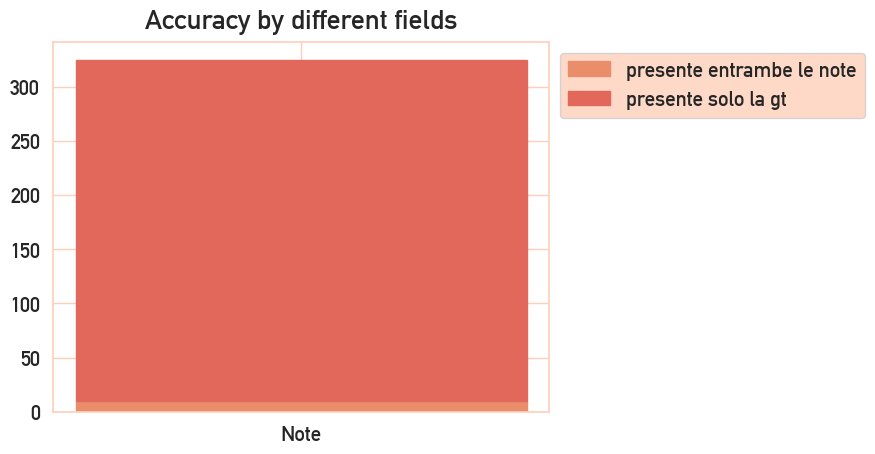

In [58]:

for model in models:
    dict_results = dict(df.loc[(df["model"] == model) & (df["sentence_similarity_score_note"] <= 0.1)].groupby(['NotePresenti'])['REF_INDICE'].count())
    data = list(dict_results.values())
    wedge_labels = list(dict_results.keys())

    bottom  = np.zeros(1)
    for (boolean,weight),color in zip(dict_results.items(),colors):
        plt.bar("Note",weight,0.5,label=boolean,color=color, edgecolor=color, bottom=bottom)
        bottom += weight
    
    plt.title(f"Accuracy by different fields", pad=10)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

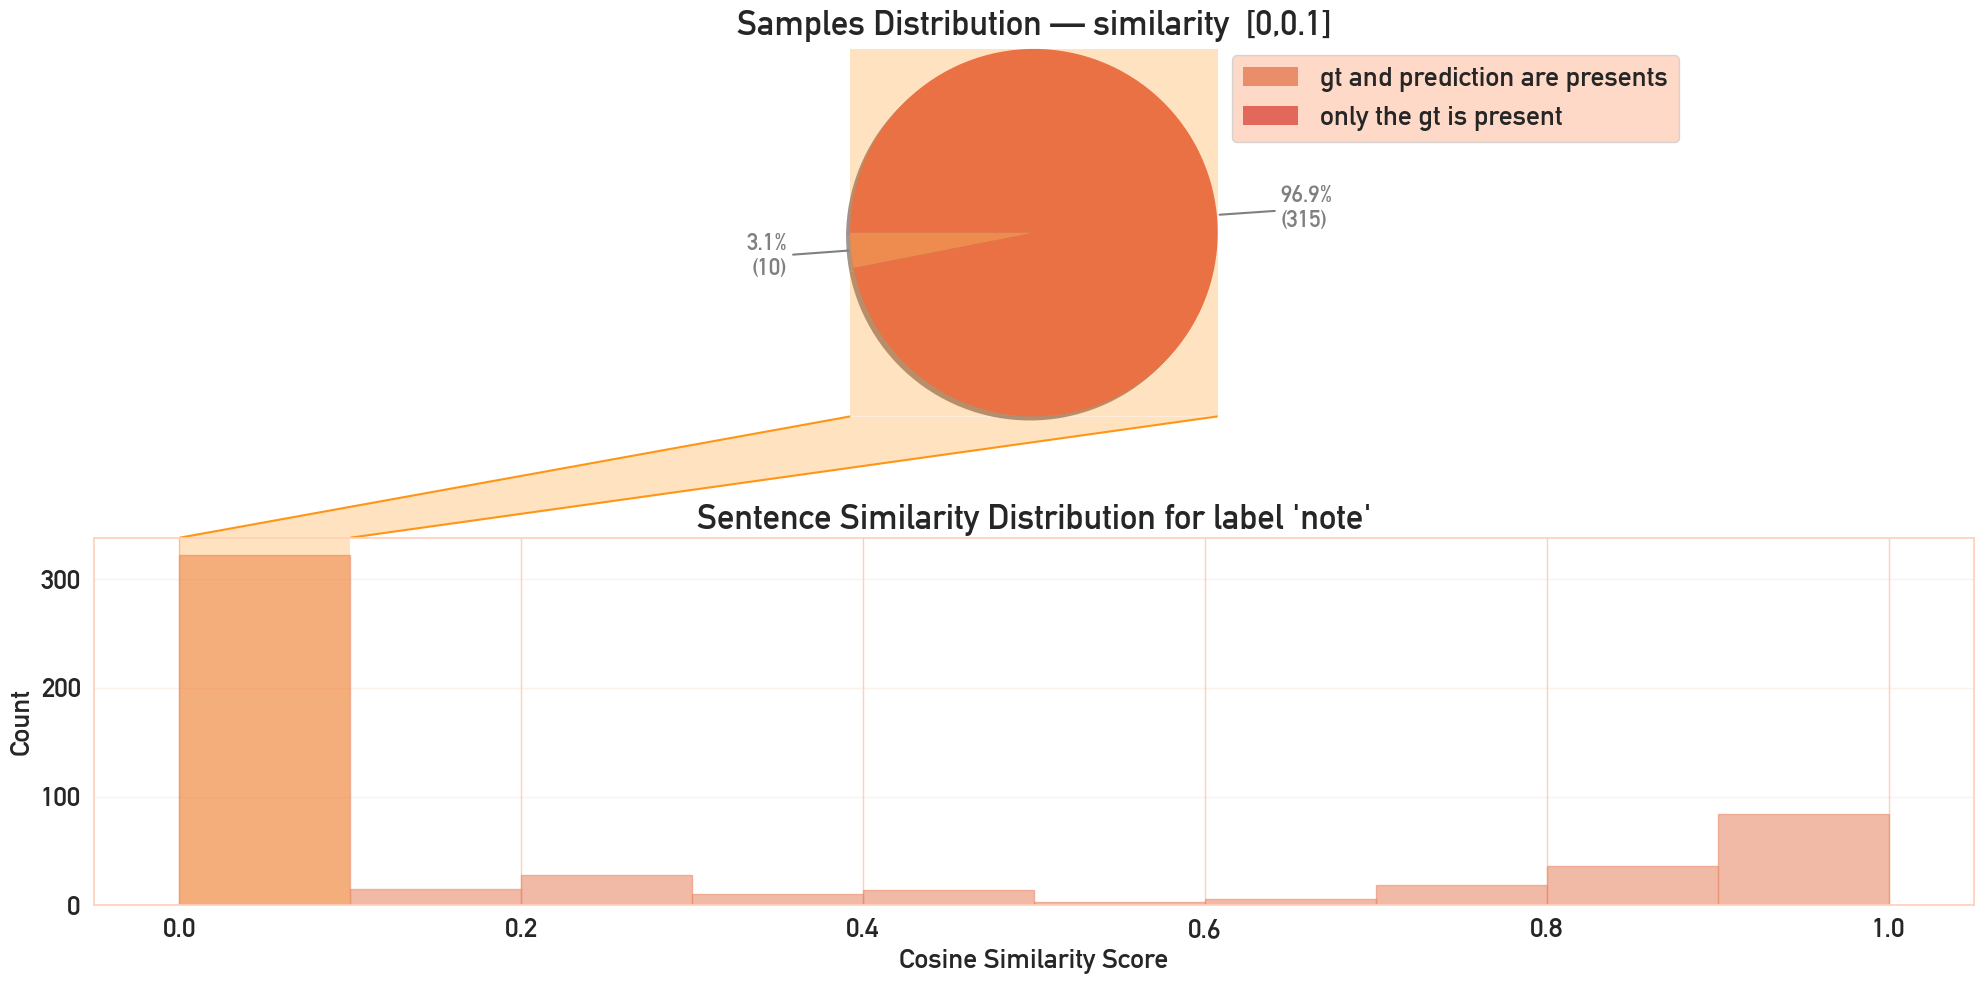

In [20]:
from matplotlib.transforms import Bbox, TransformedBbox
from mpl_toolkits.axes_grid1.inset_locator import (
    BboxConnector, BboxConnectorPatch, BboxPatch
)

# ── Connettori visivi ─────────────────────────────────────────────────────────
def connect_bbox(bbox1, bbox2, loc1a, loc2a, loc1b, loc2b,
                 prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {**prop_lines,
                        "alpha": prop_lines.get("alpha", 1) * 0.2,
                        "clip_on": False}
    c1  = BboxConnector(bbox1, bbox2, loc1=loc1a, loc2=loc2a, clip_on=False, **prop_lines)
    c2  = BboxConnector(bbox1, bbox2, loc1=loc1b, loc2=loc2b, clip_on=False, **prop_lines)
    bp1 = BboxPatch(bbox1, **prop_patches)
    bp2 = BboxPatch(bbox2, **prop_patches)
    p   = BboxConnectorPatch(bbox1, bbox2,
                              loc1a=loc1a, loc2a=loc2a,
                              loc1b=loc1b, loc2b=loc2b,
                              clip_on=False, **prop_patches)
    return c1, c2, bp1, bp2, p


def link_region_to_axes(ax_main, ax_secondary, xmin, xmax, **kwargs):
    bbox      = Bbox.from_extents(xmin, 0, xmax, 1)
    bbox_main = TransformedBbox(bbox, ax_main.get_xaxis_transform())
    bbox_sec  = TransformedBbox(Bbox.unit(), ax_secondary.transAxes)

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.25}
    c1, c2, bp1, bp2, p = connect_bbox(
        bbox_main, bbox_sec,
        loc1a=2, loc2a=3,
        loc1b=1, loc2b=4,
        prop_lines=kwargs, prop_patches=prop_patches
    )
    ax_main.add_patch(bp1)
    ax_secondary.add_patch(bp2)
    ax_secondary.add_patch(c1)
    ax_secondary.add_patch(c2)
    ax_secondary.add_patch(p)


# ── Layout ────────────────────────────────────────────────────────────────────
fig, axs = plt.subplot_mosaic(
    [["detail"], ["main"]],
    figsize=(20, 10),
    height_ratios=[1, 1]
)

# ── MAIN: istogramma cosine similarity ───────────────────────────────────────
all_data = []
for model in models:
    data = df.loc[
        (df['model'] == model) &
        (df['sentence_similarity_score_note'].notna())
    ]['sentence_similarity_score_note']
    all_data.append(data)

min_val = min(d.min() for d in all_data)
max_val = max(d.max() for d in all_data)
bins = np.linspace(min_val, max_val, 11)

for i, model in enumerate(models):
    axs["main"].hist(
        all_data[i],
        bins=bins,
        histtype="bar",
        alpha=0.6,
        edgecolor=colors[0],
        color=colors[0],
        label=model
    )

axs["main"].set_title("Sentence Similarity Distribution for label 'note'")
axs["main"].set_xlabel("Cosine Similarity Score")
axs["main"].set_ylabel("Count")
axs["main"].grid(axis="y", alpha=0.3)

# ── DETAIL: pie chart failure_reason_2 per similarity ≤ 0.1 ──────────────────
axs["detail"].set_aspect("equal")   # indispensabile per la pie

model = models[0]                   # un solo modello → una sola pie
dict_results = dict(
    df.loc[
        (df["model"] == model) &
        (df["sentence_similarity_score_note"] <= 0.1)
    ].groupby(['NotePresenti'])['REF_INDICE'].count()
)
data         = list(dict_results.values())
wedge_labels = list(dict_results.keys())
total        = sum(data)
radius       = 1.25   # leggermente ridotto rispetto all'originale (1.25)
                     # per non uscire dai bordi dell'asse piccolo

wedges, texts = axs["detail"].pie(
    data,
    colors=colors,
    radius=radius,
    startangle=180,
    wedgeprops=dict(linewidth=0),
    shadow=True
)

for wedge, val in zip(wedges, data):
    pct        = val / total * 100
    label_text = f"{pct:.1f}%\n({val})"

    angle   = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)

    x_edge  = radius * np.cos(angle)
    y_edge  = radius * np.sin(angle)

    r_label = radius * 1.35          # ridotto (era 1.4) per stare nell'asse
    x_label = r_label * np.cos(angle)
    y_label = r_label * np.sin(angle)

    axs["detail"].annotate(
        label_text,
        xy=(x_edge, y_edge),
        xytext=(x_label, y_label),
        ha='left' if x_label > 0 else 'right',
        va='center',
        fontsize=17,              # ridotto per l'asse piccolo (era 12)
        fontweight='bold',
        color="gray",
        arrowprops=dict(arrowstyle='-', color='gray', lw=1.5)
    )

axs["detail"].legend(
    wedges, wedge_labels,
    loc="upper left",
    bbox_to_anchor=(1, 0.25, 1, 0.77),
    frameon=True,
    facecolor="#fed0bb"
)
axs["detail"].set_title("Samples Distribution — similarity  [0,0.1]", pad=10)

# ── Connettori ────────────────────────────────────────────────────────────────
link_region_to_axes(
    axs["main"], axs["detail"],
    xmin=0, xmax=0.1,
    color="darkorange", lw=1.5, alpha=0.9
)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, "Sentence Similarity Distribution for label 'note inefficiency'")

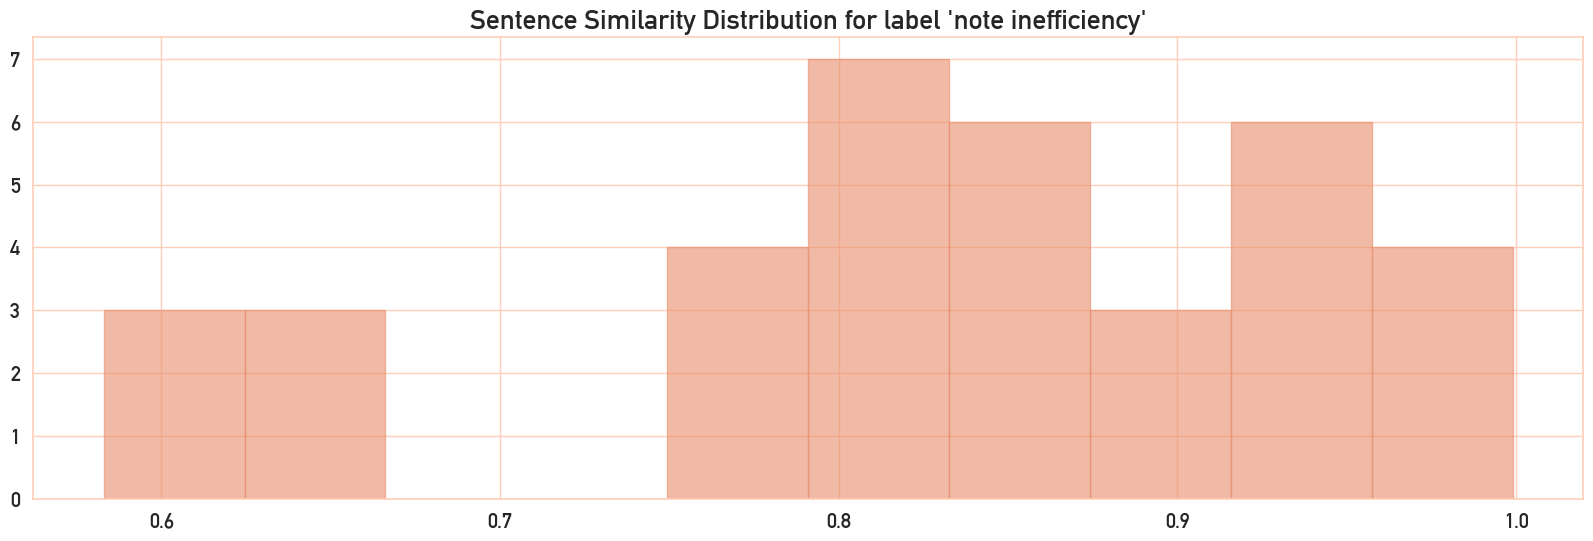

In [ ]:
# distribuzione cosine similarity per il campo note
plt.figure(figsize=(20,6))
all_data = []
for model in models:
    data = df.loc[(df['model'] == model) & 
                  (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_inefficiency']
    all_data.append(data)

min_val = min([d.min() for d in all_data])
max_val = max([d.max() for d in all_data])
bins = np.linspace(min_val, max_val, 11) ## 11 val -> 10 bin
for i, model in enumerate(models):
    plt.hist(all_data[i],
             bins=bins,  # Usa i bin espliciti invece di solo il numero
             histtype="bar",  # Cambiato da "barstacked"
             alpha=0.6,  # Aggiungi trasparenza per vedere sovrapposizioni
             edgecolor=colors[0],
             color=colors[0])
plt.title("Sentence Similarity Distribution for label 'note'")

0.499 	+-0.03383306145377662
0.477 	+-0.03379731471363948
0.536 	+-0.033745319700545846
0.262 	+-0.029754385702412324
0.281 	+-0.030415136298102444
0.851 	+-0.024095174513040465


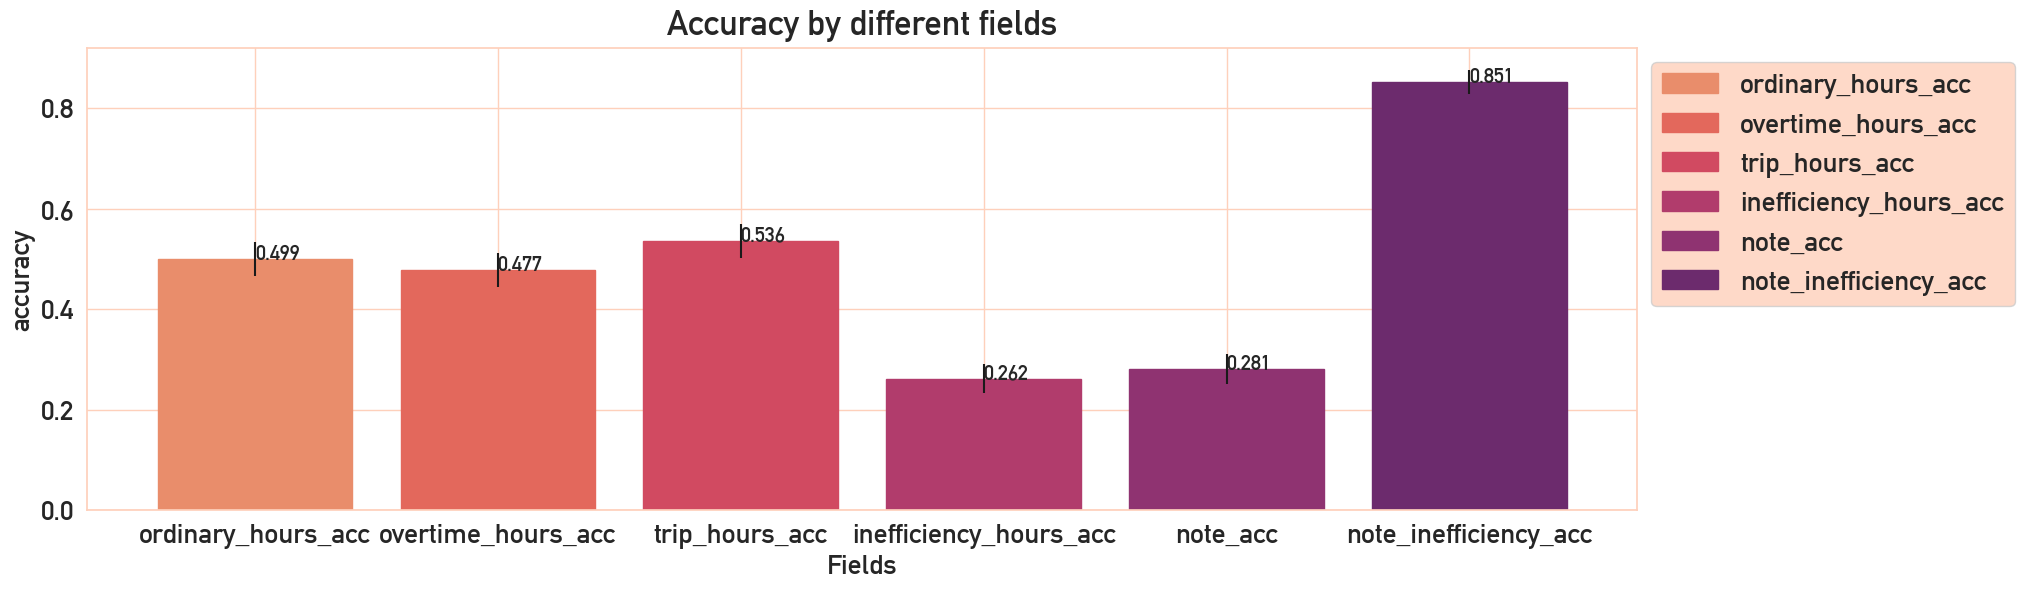

In [11]:
# chart per il display tot per ogni misurazione
# accuracy a tipi di schema
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i], size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())


for model in models:
    media_group = []
    CI_group = []
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    fields=['ordinary_hours_acc', 'overtime_hours_acc', 'trip_hours_acc','inefficiency_hours_acc','note_acc','note_inefficiency_acc']
    for column in columns:
            
        acc_media = round(df.loc[(df['model'] == model)][column].mean(),3)
        n = len(df.loc[(df['model'] == model)])
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")
    plt.figure(figsize=(20,6))
    plt.bar(fields,media_group, yerr=CI_group, label=fields, color=colors, edgecolor=edgecolors)
    add_labels(fields,media_group)
    plt.title(f"Accuracy by different fields", pad=10)
    plt.xlabel("Fields")
    plt.xticks(fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


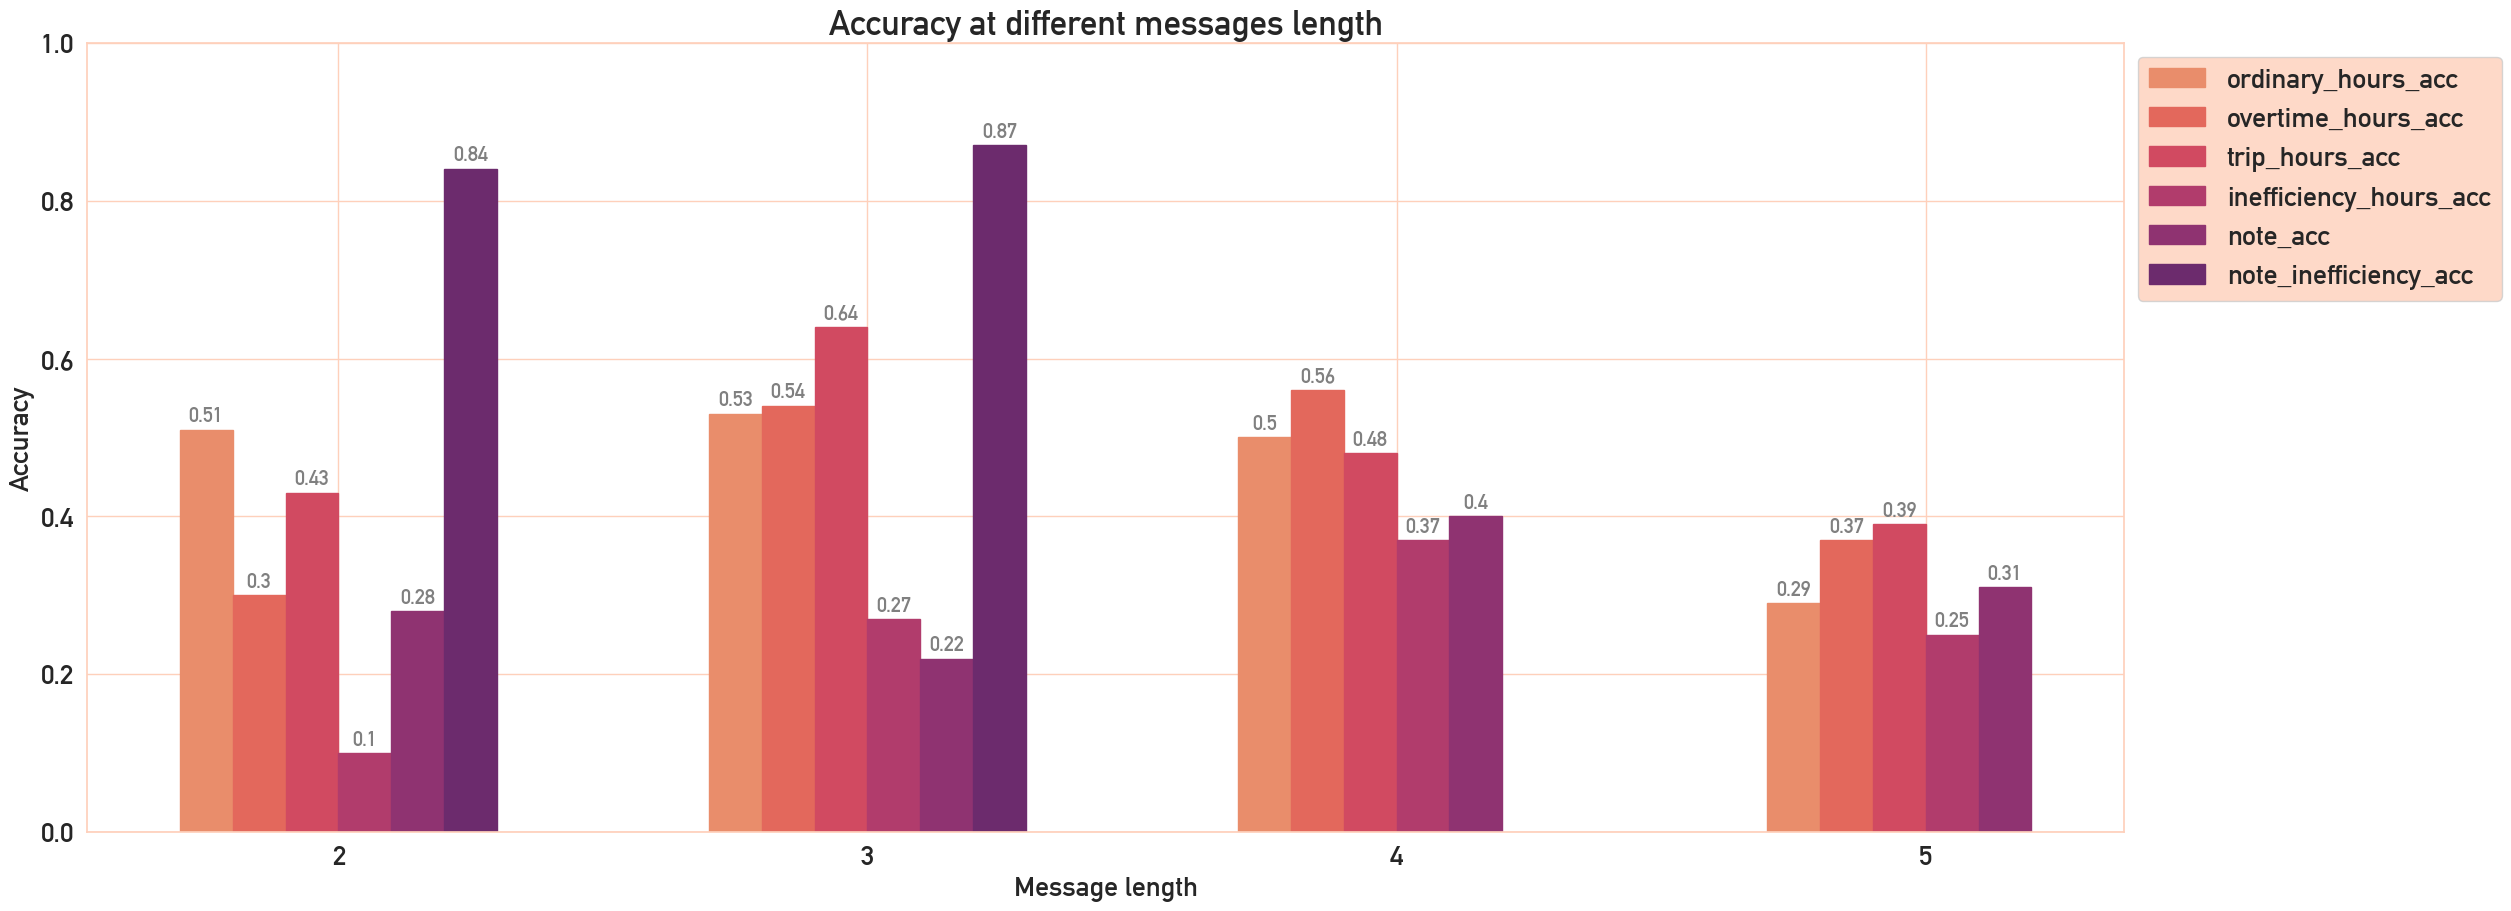

In [ ]:
# chart per fare il display accuracy totale  al variare del flow

l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    fields=['ordinary_hours_acc', 'overtime_hours_acc', 'trip_hours_acc','inefficiency_hours_acc','note_acc','note_inefficiency_acc']
    # init il dict
    for field in fields:
        metric_means[field] = ()

    for length_m in l_msg:
        for column,field in zip(columns,fields):
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),2),)
                metric_means[field] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),2),)
                metric_means[field] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(25,9), layout='constrained')
    for color,(attribute, measurement) in zip(colors,metric_means.items()):
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=color,edgecolor=color)
        ax.bar_label(rects, padding=3, label_type='edge',color="gray",size=15)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    
    n_metrics = len(metric_means)
    center_offset = width * (n_metrics - 1) / 2
    ax.set_ylabel('Accuracy')
    ax.set_xlabel("Message length")
    ax.set_title(f'Accuracy at different messages length')
    ax.set_xticks(x + center_offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")
    ax.set_ylim(0,1)

([], [])

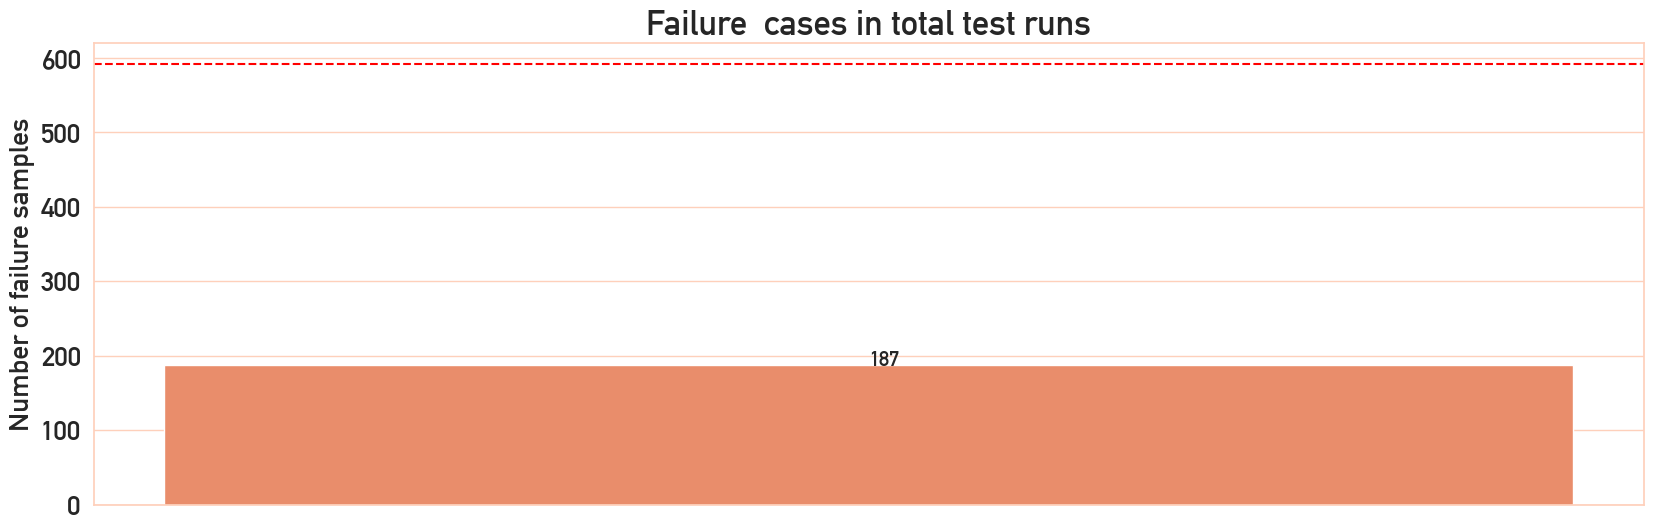

In [8]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i],size=15)

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test runs")
plt.ylabel("Number of failure samples")
plt.xticks([])

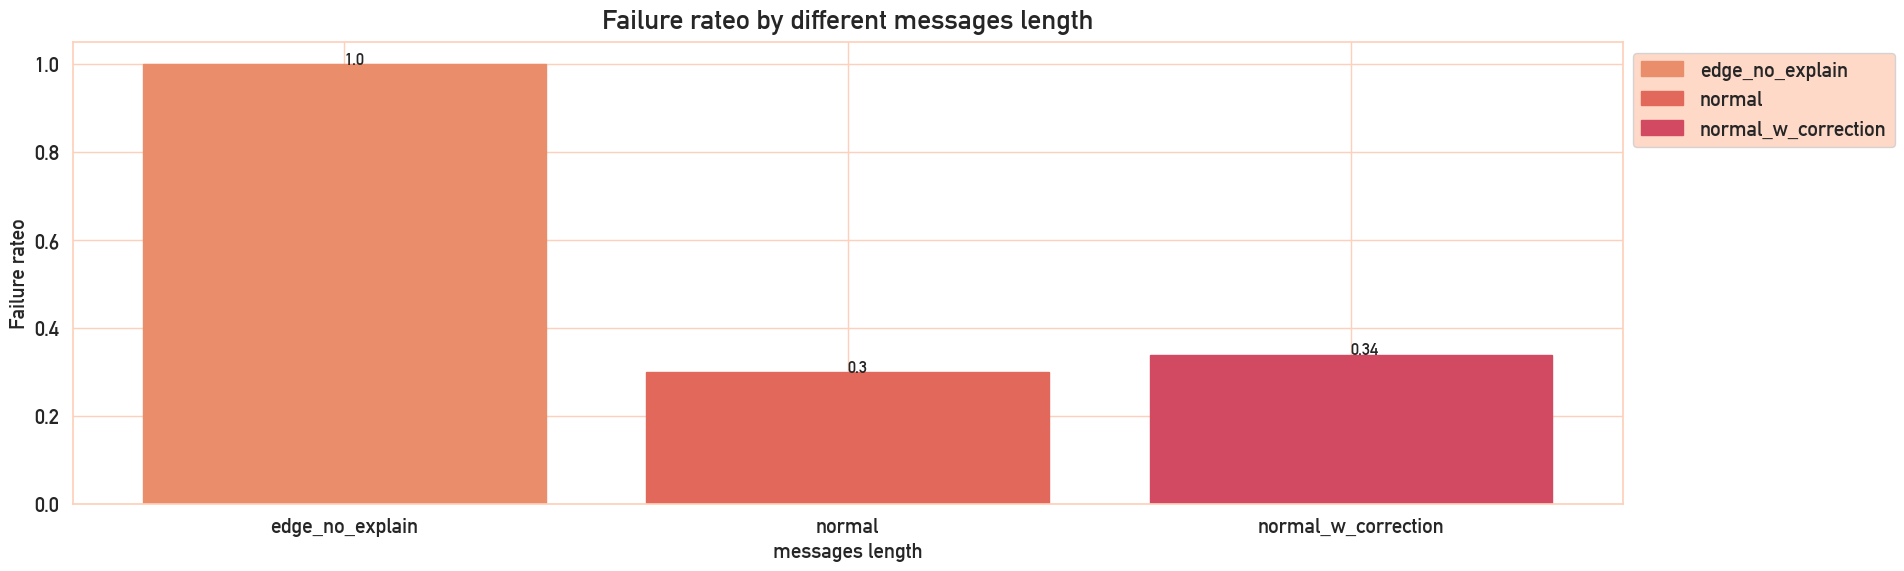

In [143]:
# bar charts del count dei failure a seconda della lunghezza della conversazione
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    rateos = []
    
    schemas = np.sort(df['TYPE_EVAL'].unique())
    for schema in schemas:
        
        count_non_na = df.loc[(df['model'] == model) & (df['TYPE_EVAL'] == schema)]['failure_reason'].notna().sum()
        count_all = df.loc[(df['model'] == model) & (df['TYPE_EVAL'] == schema)]['REF_INDICE'].count() 
        r = round(count_non_na / count_all,2)
        rateos.append(r)

    plt.figure(figsize=(20,6))
    plt.bar(schemas,rateos,label=schemas, color=colors, edgecolor=edgecolors)
    add_labels(schemas,rateos)
    plt.title(f"Failure rateo by different messages length", pad=10)
    plt.xlabel("messages length")
    plt.xticks(schemas)
    plt.ylabel("Failure rateo")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


In [ ]:
# bar charts del count dei failure a seconda dello schema
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    rateos = []
    
    l_msg = np.sort(df['L_MESSAGGI'].unique())
    for length_m in l_msg:
        
        count_non_na = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)]['failure_reason'].notna().sum()
        count_all = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)]['REF_INDICE'].count() 
        r = round(count_non_na / count_all,2)
        rateos.append(r)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,rateos,label=l_msg, color=colors, edgecolor=edgecolors)
    add_labels(l_msg,rateos)
    plt.title(f"Failure rateo by different messages length", pad=10)
    plt.xlabel("messages length")
    plt.xticks(l_msg)
    plt.ylabel("Failure rateo")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


In [9]:
import ast

def func_failure(row):
    len_msg = row['L_MESSAGGI']
    if row['count_function_calls'] != len_msg:
        if row['count_function_calls'] == 0:
             return "Agent don't call any tool at the start"
        return "Agent calls to tools are disalignment with the messages"
    
        
    # controlliamo che l'ultima function call è push_data:
    l = ast.literal_eval(row['function_calls'])
    if l[-1] != 'push_data':
        return "Agent don't finish with push_data"
    else:
        match row['push_data_response']:
                case True:
                    return None
                case '1.0': return "push_data_response is a string"
                case 'True': return "push_data_response is a string"
                case 'False': return "Agent put False as params in push_data"
                case _: return "push_data_response is null"

df['failure_reason_2'] = df.apply(func_failure, axis=1)

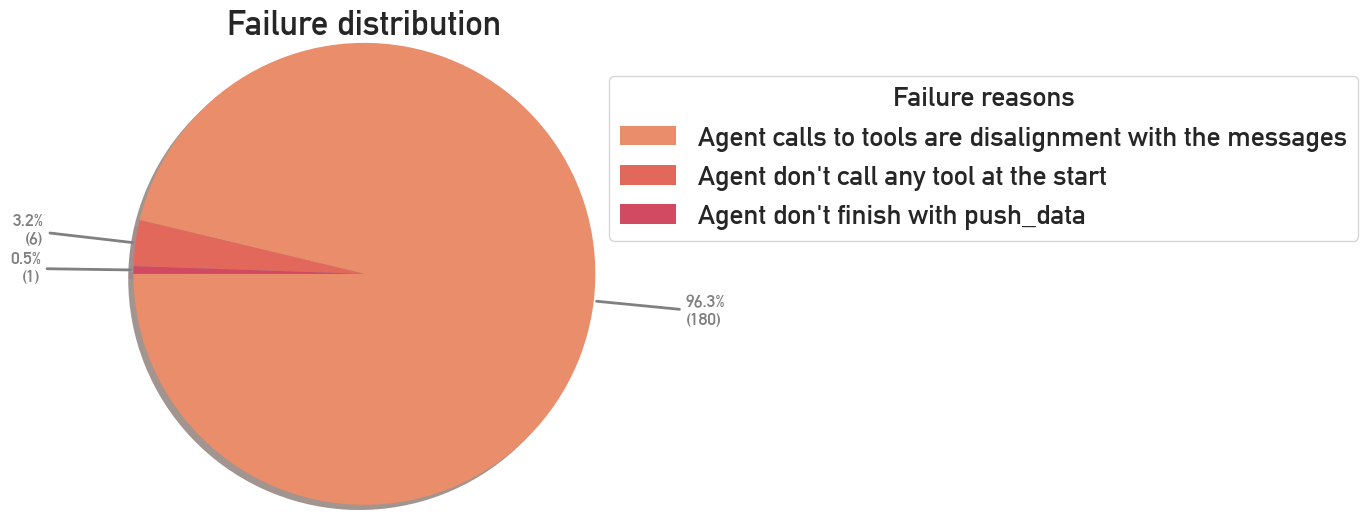

In [10]:
for model, label, color in zip(models, labels, colors):
    fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))

    def func(pct, all):
        absolute = int(np.round(pct / 100. * np.sum(all)))
        return f"{pct:.1f}%\n({absolute})"

    dict_results = dict(df.loc[df['model'] == model].groupby(['failure_reason_2'])['REF_INDICE'].count())
    data = list(dict_results.values())
    wedge_labels = list(dict_results.keys())
    total = sum(data)
    radius = 1.25

    # Niente autopct — gestiamo noi le label
    wedges, texts = ax.pie(data, colors=colors,
                           radius=radius, startangle=180, wedgeprops=dict(linewidth=0), shadow=True)

    for wedge, val in zip(wedges, data):
        pct = val / total * 100
        label_text = f"{pct:.1f}%\n({val})"

        # Angolo centrale della fetta (in gradi → radianti)
        angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)

        # Punto sul bordo del pie (partenza freccia)
        x_edge = radius * np.cos(angle)
        y_edge = radius * np.sin(angle)

        # Punto dell'etichetta (più lontano)
        r_label = radius * 1.4
        x_label = r_label * np.cos(angle)
        y_label = r_label * np.sin(angle)

        ax.annotate(
            label_text,
            xy=(x_edge, y_edge),          # punta della freccia (bordo fetta)
            xytext=(x_label, y_label),     # posizione etichetta
            ha='left' if x_label > 0 else 'right',
            va='center',
            fontsize=13,
            fontweight='bold',
            color="gray",
            arrowprops=dict(arrowstyle='-', color='gray', lw=2.0)
        )

    ax.legend(wedges, wedge_labels,
              title="Failure reasons",
              loc="center left",
              bbox_to_anchor=(1, 0.25, 0.5, 1))

    ax.set_title(f"Failure distribution")
    plt.show()